In [2]:
import kagglehub
path = kagglehub.dataset_download("yashdevladdha/uber-ride-analytics-dashboard")

100%|██████████| 16.5M/16.5M [00:00<00:00, 41.7MB/s]

Extracting files...


In [7]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv(path+"/ncr_ride_bookings.csv")
df.head()


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [9]:
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


In [10]:
df.tail()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI
149999,2024-03-10,15:38:03,"""CNR3447390""",Completed,"""CID4108667""",Premier Sedan,Ashok Park Main,Gurgaon Sector 29,3.5,33.7,...,NaN,NaN,NaN,NaN,NaN,806.0,21.19,4.6,4.9,Credit Card


In [11]:
df.isnull().sum()

,0
Date,0
Time,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,10500
Avg CTAT,48000


In [13]:
df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='object')

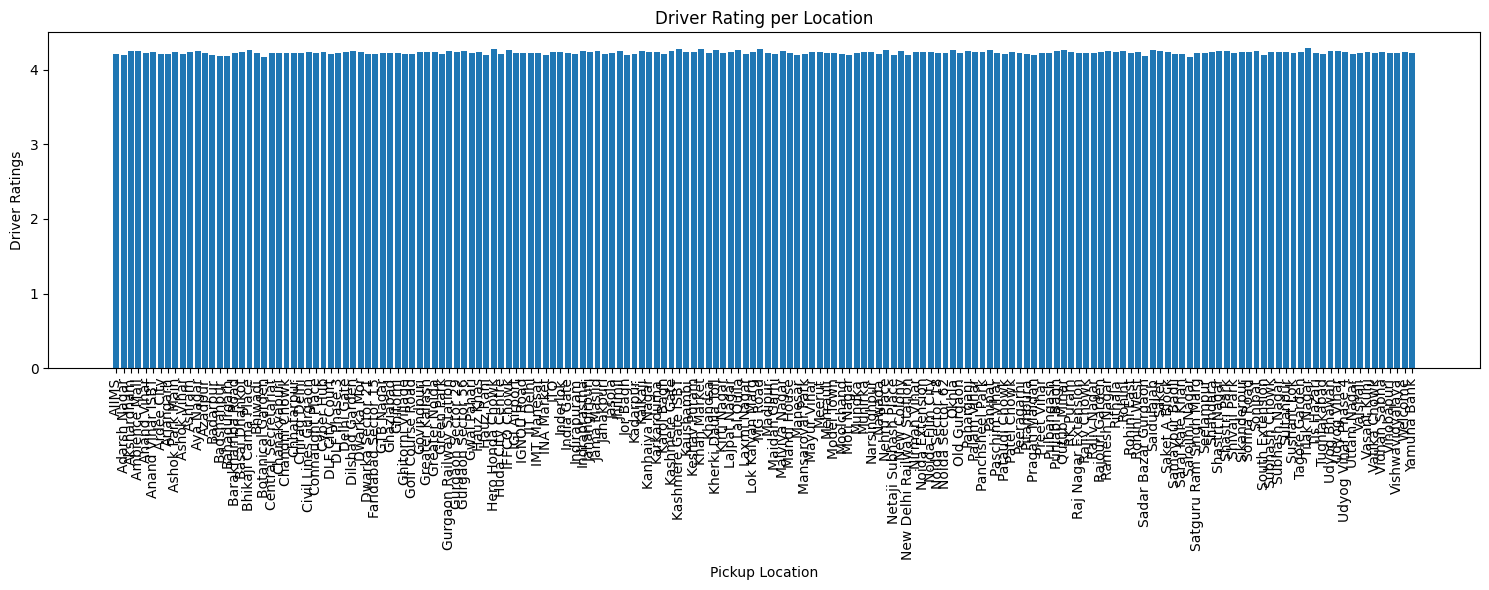

In [23]:
avg_ratings = df.groupby('Pickup Location')['Driver Ratings'].mean()

plt.figure(figsize=(15, 6))
plt.bar(avg_ratings.index, avg_ratings.values)

plt.title("Driver Rating per Location")
plt.xlabel("Pickup Location")
plt.ylabel("Driver Ratings")
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

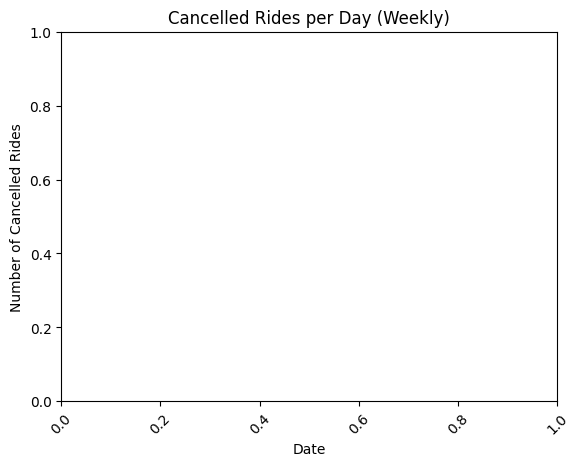

In [36]:
plt.title("Cancelled Rides per Day (Weekly)")
plt.xlabel("Date")
plt.ylabel("Number of Cancelled Rides")
plt.xticks(rotation=45)


plt.show()


<Axes: title={'center': 'Booking Status Distribution'}, xlabel='Booking Status'>

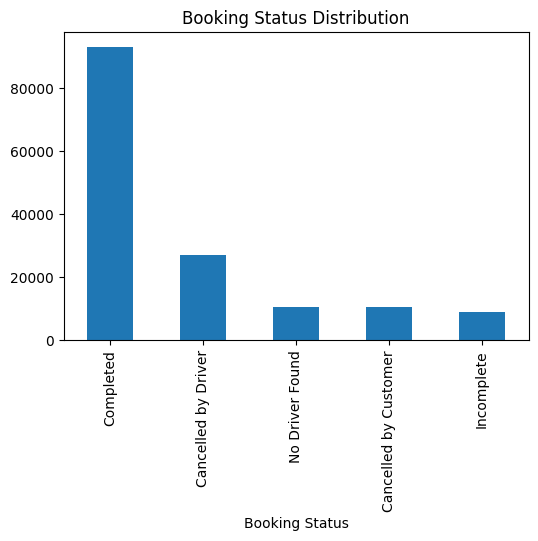

In [27]:
df['Booking Status'].value_counts().plot(kind='bar', figsize=(6,4), title="Booking Status Distribution")


<Axes: title={'center': 'Cancellation Comparison'}, ylabel='Number of Rides'>

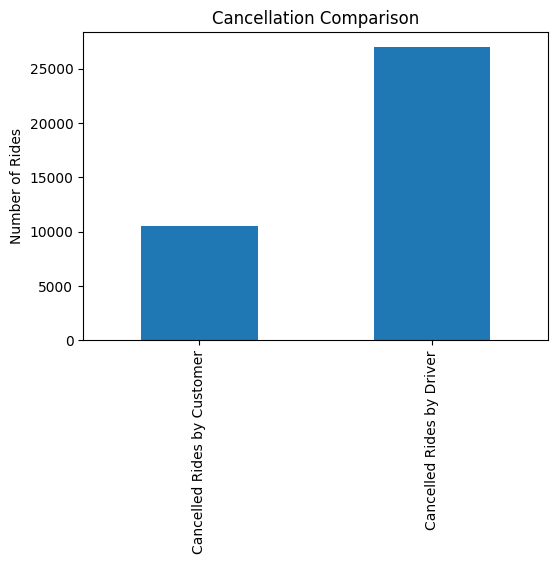

In [28]:
cancel_data = df[['Cancelled Rides by Customer', 'Cancelled Rides by Driver']].sum()

cancel_data.plot(
    kind='bar',
    figsize=(6,4),
    title="Cancellation Comparison",
    ylabel="Number of Rides"
)


<Axes: title={'center': 'Daily Ride Demand'}, xlabel='Date'>

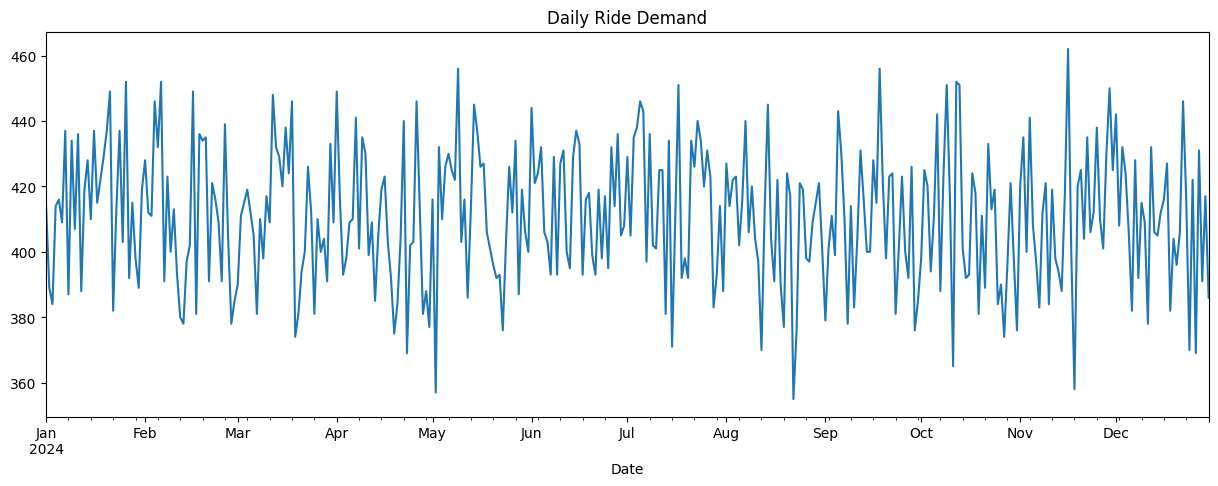

In [41]:
df['Date'] = pd.to_datetime(df['Date'])

daily_rides = df.groupby('Date').size()

daily_rides.plot(figsize=(15,5), title="Daily Ride Demand")


<Axes: title={'center': 'Avg Booking Value per Vehicle Type'}, xlabel='Vehicle Type', ylabel='Booking Value'>

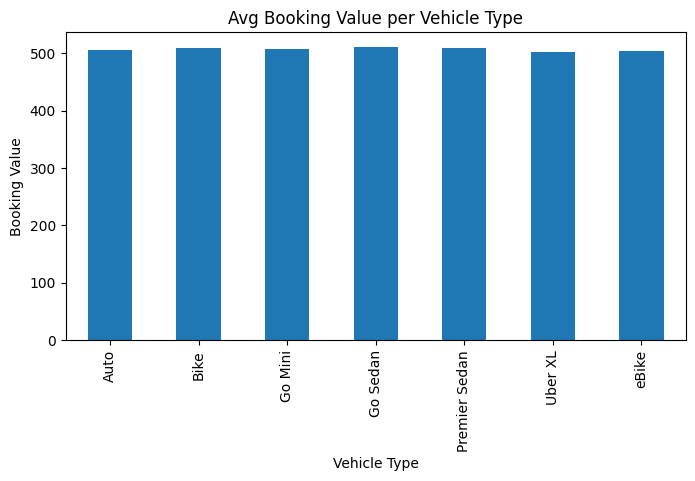

In [31]:
vehicle_revenue = df.groupby('Vehicle Type')['Booking Value'].mean()

vehicle_revenue.plot(
    kind='bar',
    figsize=(8,4),
    title="Avg Booking Value per Vehicle Type",
    ylabel="Booking Value"
)


<Axes: title={'center': 'Top 10 Pickup Locations'}, xlabel='Pickup Location'>

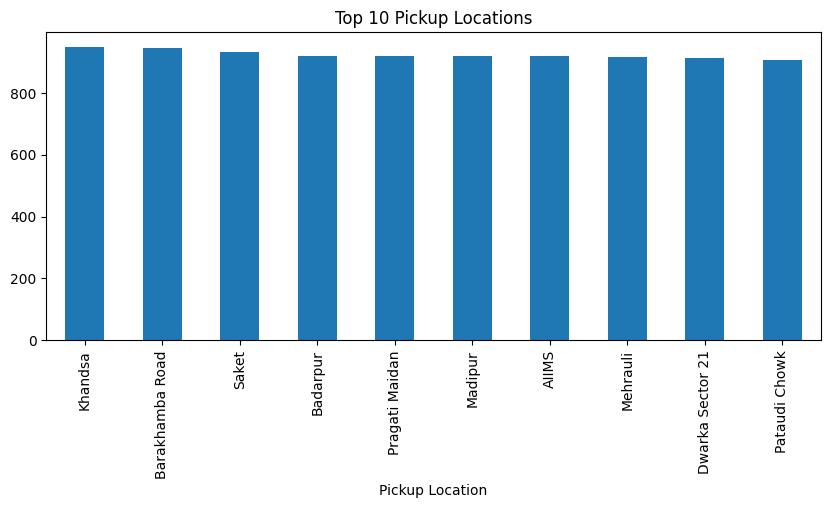

In [32]:
top_locations = df['Pickup Location'].value_counts().head(10)

top_locations.plot(
    kind='bar',
    figsize=(10,4),
    title="Top 10 Pickup Locations"
)


<Axes: title={'center': 'Payment Method Usage'}, ylabel='count'>

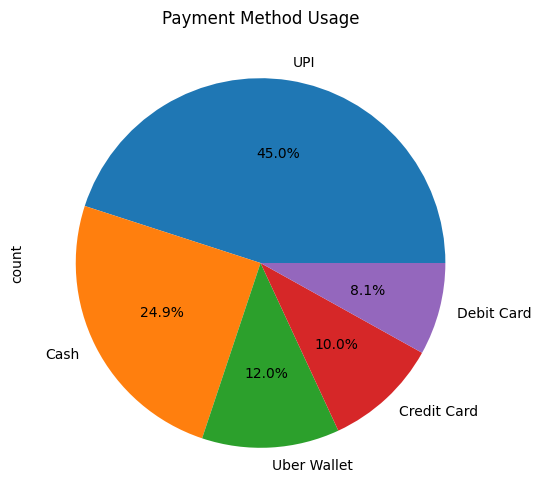

In [33]:
df['Payment Method'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6),
    title="Payment Method Usage"
)


In [39]:
plt.bar(df['Driver Ratings'], df['Customer Rating'])
plt.xlabel('Driver Ratings')
plt.ylabel('Customer Rating')
plt.title('Driver vs Customer Ratings Distribution')

Text(0.5, 1.0, 'Driver vs Customer Ratings Distribution')

Error in callback <function _draw_all_if_interactive at 0x7e5e2016f920> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7e5e2016cea0> (for post_execute):


KeyboardInterrupt: 

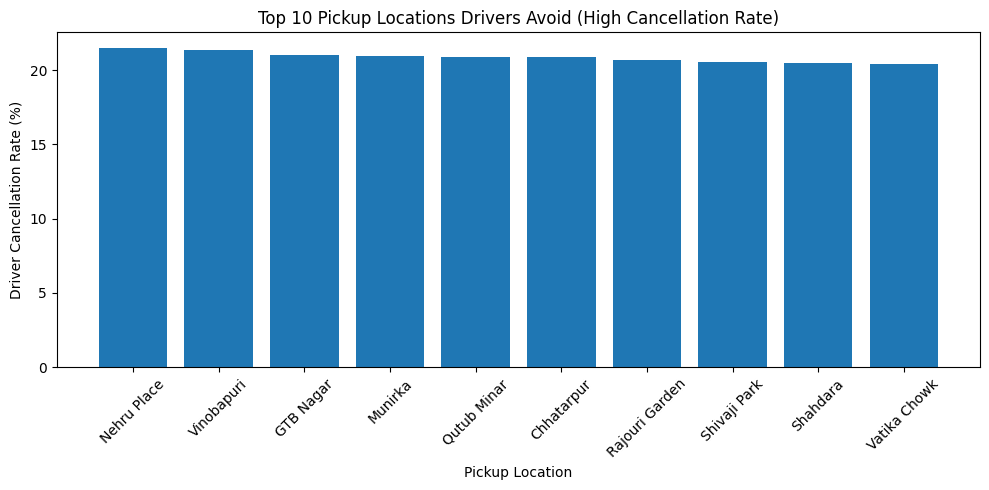

In [42]:
driver_cancel_df = df[df['Cancelled Rides by Driver'] == 1]
total_bookings = df['Pickup Location'].value_counts()
driver_cancellations = driver_cancel_df['Pickup Location'].value_counts()
cancel_rate_df = pd.DataFrame({
    'Total Bookings': total_bookings,
    'Driver Cancellations': driver_cancellations
}).fillna(0)
cancel_rate_df['Driver Cancellation Rate (%)'] = (
    cancel_rate_df['Driver Cancellations'] / cancel_rate_df['Total Bookings']
) * 100
avoid_locations = cancel_rate_df.sort_values(
    by='Driver Cancellation Rate (%)',
    ascending=False
)
avoid_locations.head(10)
top_avoid = avoid_locations.head(10)
plt.figure(figsize=(10,5))
plt.bar(top_avoid.index, top_avoid['Driver Cancellation Rate (%)'])
plt.title("Top 10 Pickup Locations Drivers Avoid (High Cancellation Rate)")
plt.xlabel("Pickup Location")
plt.ylabel("Driver Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [43]:
driver_cancel_fare = (
    df[df['Cancelled Rides by Driver'] == 1]
    .groupby('Pickup Location')['Booking Value']
    .mean()
    .sort_values()
)

driver_cancel_fare.head(10)


,Booking Value
Pickup Location,
AIIMS,NaN
Adarsh Nagar,NaN
Akshardham,NaN
Ambience Mall,NaN
Anand Vihar,NaN
Anand Vihar ISBT,NaN
Ardee City,NaN
Arjangarh,NaN
Ashok Park Main,NaN


In [44]:
driver_cancel_distance = (
    df[df['Cancelled Rides by Driver'] == 1]
    .groupby('Pickup Location')['Ride Distance']
    .mean()
    .sort_values(ascending=False)
)

driver_cancel_distance.head(10)


,Ride Distance
Pickup Location,
AIIMS,NaN
Adarsh Nagar,NaN
Akshardham,NaN
Ambience Mall,NaN
Anand Vihar,NaN
Anand Vihar ISBT,NaN
Ardee City,NaN
Arjangarh,NaN
Ashok Park Main,NaN


In [45]:
driver_cancel_reasons = (
    df[df['Cancelled Rides by Driver'] == 1]
    ['Driver Cancellation Reason']
    .value_counts()
)

driver_cancel_reasons


,count
Driver Cancellation Reason,
Customer related issue,6837
The customer was coughing/sick,6751
Personal & Car related issues,6726
More than permitted people in there,6686
